# Machine learning models

This notebook contains the code for the lecture on linear regression and machine learning models for the Machine Learning for Chemical Engineers course.

You can find more information at: https://github.com/AntonioE89/Machine-Learning-for-Chemical-Engineering

The code presented here is for educational purposes and is not optimized for performance.

In [21]:
import numpy as np                                 # Numerical computations
import matplotlib.pyplot as plt                    # Plotting
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal        # Statistics
from scipy.optimize import minimize                # Optimization
from sklearn.linear_model import LinearRegression  # Machine learning

# Training Dataset
In this section, we generate synthetic data that will be used to train and evaluate our machine learning models. We start with 1-dimensional input values to simplify visualization and understanding of model behavior.

In [22]:
######################
# 1-Dimensional data #
######################

x_data = [-12, -10, -5, -2.5, 2, 4, 6, 7.5]  # define training data
Xtrain = np.array(x_data).reshape(-1, 1)     # reshape data

In [23]:
Xtrain

array([[-12. ],
       [-10. ],
       [ -5. ],
       [ -2.5],
       [  2. ],
       [  4. ],
       [  6. ],
       [  7.5]])

# Target Functions
These are the mathematical functions that serve as ground truth for our supervised learning models. By fitting models to these functions, we can assess how well different ML algorithms approximate them.

In [24]:
###########################
# 1-Dimensional functions #
###########################

def sin_square(x):
    return np.sin(x) + (x/5)**2

def gauss3(x):
    # Define parameters of Gaussians
    gaus_params = np.array([[1., 2., -8.], [1.5, 1.5, 0.], [1.4, 1., 5.]])
    a, std, m = gaus_params.T
    # Initialize the evaluation array
    eval = np.zeros(x.shape)
    # Compute Gaussians
    for ai, stdi, mi in zip(a, std, m):
        eval += ai / (stdi * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mi) / stdi) ** 2)
    return -eval


In [25]:
# computing true output data Y
Ytrain_ss = sin_square(Xtrain)
Ytrain_3g = gauss3(Xtrain)

# computing true function values for visualization
x_points = np.linspace(-15, 15.0, num=100).reshape(-1, 1)
Ytrue_ss = sin_square(x_points)
Ytrue_3g = gauss3(x_points)


In [26]:
Ytrain_3g

array([[-0.02699548],
       [-0.12098536],
       [-0.06630108],
       [-0.10402392],
       [-0.17021541],
       [-0.350155  ],
       [-0.33889284],
       [-0.02454111]])

# Utility Functions
This section contains helper functions used to evaluate model performance and visualize predictions. These utilities support training diagnostics and comparison between models.

In [27]:
####################
# evaluate ML model
###################

def evalML(x_points, modelss, model3g, n_d=100, GP_model=False):
    x_points = np.linspace(-15, 15.0, num=n_d).reshape(-1, 1)
    Yplot_ss, Yplot_3g = [], []

    if GP_model:
        Yplot_ss_var, Yplot_3g_var = [], []

    for xp_ in x_points:
        if GP_model:
            mss, sss = modelss.predict(xp_.reshape(-1, 1), return_std=True)
            m3g, s3g = model3g.predict(xp_.reshape(-1, 1), return_std=True)

            Yplot_ss.append(mss[0])
            Yplot_3g.append(m3g[0])
            Yplot_ss_var.append(sss[0])
            Yplot_3g_var.append(s3g[0])
        else:
            yp_ss = modelss.predict(xp_.reshape(-1, 1))
            yp_3g = model3g.predict(xp_.reshape(-1, 1))

            Yplot_ss.append(yp_ss[0])
            Yplot_3g.append(yp_3g[0])

    if GP_model:
        return np.array(Yplot_ss), np.array(Yplot_3g), \
        np.array(Yplot_ss_var), np.array(Yplot_3g_var)
    else:
        return np.array(Yplot_ss), np.array(Yplot_3g), x_points

In [28]:
####################
# plot performance #
####################

def plot_results(x_points, Yplot_ss, Yplot_3g, title=None,
                 Xtrain=Xtrain, Ytrue_ss=Ytrue_ss, Ytrue_3g=Ytrue_3g,
                 Yplot_ss_var=None, Yplot_3g_var=None, step_plot=False):
    """
    Plots the results on two subplots.

    Parameters:
        x_points (array-like): Points on the x-axis.
        Yplot_ss (array-like): Predictions from the first model.
        Yplot_3g (array-like): Predictions from the second model.
        Yplot_ss_var (array-like, optional): Variance of the first model's predictions.
        Yplot_3g_var (array-like, optional): Variance of the second model's predictions.
    """
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)

    # Plot for the first model
    axes[0].plot(x_points, Ytrue_ss, 'k-', lw=2)
    if step_plot == False:
        axes[0].plot(x_points, Yplot_ss, label='Model SS', color='blue')
    else:
        axes[0].step(x_points, Yplot_ss, label='Model SS', color='blue')
    axes[0].plot(Xtrain,   Ytrain_ss, 'ro', lw=2)
    if Yplot_ss_var is not None:
        axes[0].fill_between(x_points.flatten(),
                             (Yplot_ss - 1.96 * Yplot_ss_var).flatten(),
                             (Yplot_ss + 1.96 * Yplot_ss_var).flatten(),
                             color='blue', alpha=0.2)
    axes[0].set_ylabel('$\sin(x)+(x/5)^2$')
    axes[0].legend()
    axes[0].grid(True)

    # Plot for the second model
    axes[1].plot(x_points, Ytrue_3g, 'k-', lw=2)
    if step_plot == False:
        axes[1].plot(x_points, Yplot_3g, label='Model 3G', color='red')
    else:
        axes[1].step(x_points, Yplot_3g, label='Model 3G', color='red')
    axes[1].plot(Xtrain,   Ytrain_3g, 'ro', lw=2)
    if Yplot_3g_var is not None:
        axes[1].fill_between(x_points.flatten(),
                             (Yplot_3g - 1.96 * Yplot_3g_var).flatten(),
                             (Yplot_3g + 1.96 * Yplot_3g_var).flatten(),
                             color='red', alpha=0.2)
    axes[1].set_ylabel('Sum of Gaussians')
    axes[1].legend()
    axes[1].grid(True)

    # Common x-axis label
    axes[1].set_xlabel('X-axis')

    if title:
        fig.suptitle(title)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()



<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2018639983.py:32: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_ylabel('$\sin(x)+(x/5)^2$')


# Machine Learning Models
Here, we implement and train various machine learning models on the generated data. Each model will be assessed on its ability to learn the underlying target functions.

## Linear regression

In [29]:
########################
# Linear Regression #
########################

class Linear_Regression_model:

    def __init__(self, X, y):

        n_d            = X.shape[0]
        X_with_bias    = np.hstack([np.ones((n_d, 1)), X])

        # We use @ for matrix multiplication
        XT_X = X_with_bias.T @ X_with_bias
        XT_y = X_with_bias.T @ y
        I    = np.eye(XT_X.shape[0])

        # theta = (X^T * X)^-1 * X^T * y
        self.theta = np.linalg.inv(XT_X + 1e-6 * I) @ XT_y


########################
# --- Prediction --- #
########################

    def predict(self, x_new):
        # add bias
        x_new_with_bias = np.hstack([np.ones((1, 1)), x_new])

        return x_new_with_bias @ self.theta

In [30]:
# Creating a model that learns the 3 Gaussians function
LR_model_3G   = Linear_Regression_model(Xtrain, Ytrain_3g)

# Creating a model that learns the Sin + Square function
LR_model_SS   = Linear_Regression_model(Xtrain, Ytrain_ss)

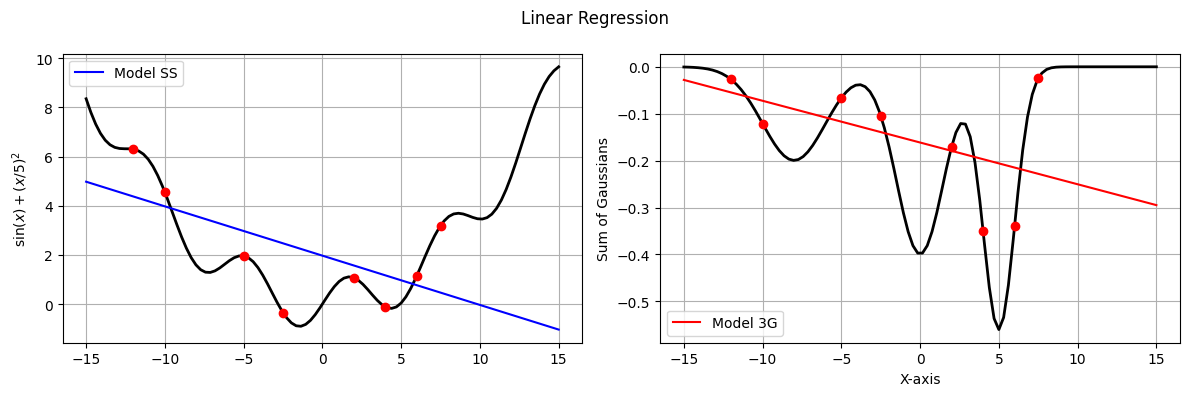

In [31]:
Y_LR_ss, Y_LR_3g, x_points  = evalML(x_points, LR_model_SS, LR_model_3G)
plot_results(x_points, Y_LR_ss, Y_LR_3g, title='Linear Regression')

## Basis functions

In [32]:
#############################
# Basis Function Regression #
#############################

class BasisF_Regression_model:

    def __init__(self, X, y):
        """Initialize the model & expand the input features into basis functions."""

        n_samples = X.shape[0]

        # Basis expansion
        X_squared = X ** 2
        X_cubed   = X ** 3
        X_sin     = np.sin(X)
        X_cos     = np.cos(X)
        bias      = np.ones((n_samples, 1))

        # Combine all features
        X_basis = np.hstack([bias, X, X_squared, X_cubed, X_sin, X_cos ])

        XT_X = X_basis.T @ X_basis
        XT_y = X_basis.T @ y
        I    = np.eye(XT_X.shape[0])

        self.theta = np.linalg.inv(XT_X + 1e-6 * I) @ XT_y

    def predict(self, x_new):
        """Predict outputs for new data."""

        Xn_squared = x_new**2
        Xn_cubed   = x_new**3
        Xn_sin     = np.sin(x_new)
        Xn_cos     = np.cos(x_new)
        bias       = np.ones((1, 1))

        xn_basis   = np.hstack([bias, x_new, Xn_squared, Xn_cubed, Xn_sin, Xn_cos])

        return xn_basis @ self.theta


In [33]:
############################
# Training basis functions #
############################

BF_model_3G = BasisF_Regression_model(Xtrain, Ytrain_3g)
BF_model_SS = BasisF_Regression_model(Xtrain, Ytrain_ss)


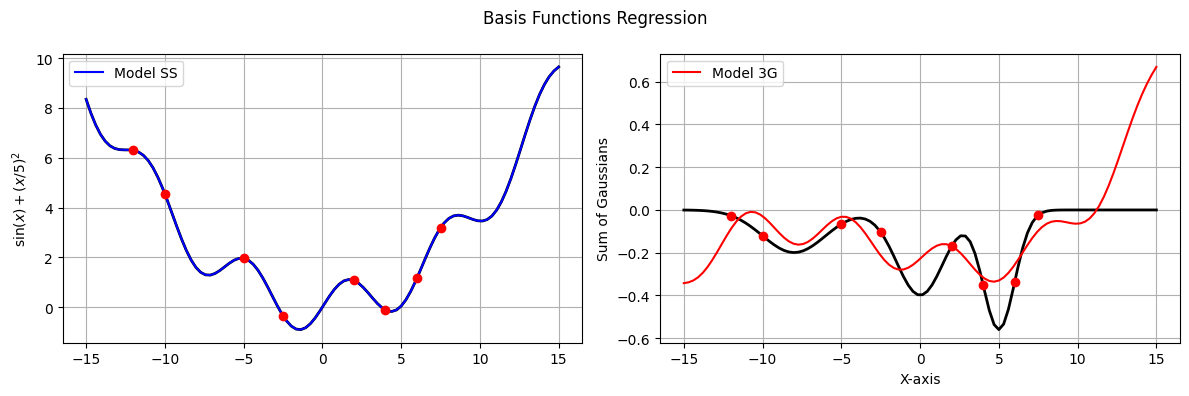

In [34]:
Y_BF_ss, Y_BF_3g, x_points  = evalML(x_points, BF_model_SS, BF_model_3G)
plot_results(x_points, Y_BF_ss, Y_BF_3g, title='Basis Functions Regression')

## Radial basis functions

In [35]:
##########################
# Radial Basis Functions #
##########################

class RBF_model:

    def __init__(self, X, Y, s=1):

        # internalize inputs
        self.X = X
        self.s = s
        # extracting dimensions
        n_p      = X.shape[0] # number of points
        try:
            self.n_y = Y.shape[1]
        except:
            print("Assumed only 1 output")
            self.n_y = 1
            Y        = Y.reshape(n_p,self.n_y)
        self.Y     = Y
        self.Ymean = np.mean(Y, axis=0)

        # starting matrix
        W_mat = np.zeros((n_p, n_p))

        # Constructing matrix W_mat
        # Note: this loop can be made faster (e.g. with np.vectorize)
        for p_i in range(n_p):
            for p_j in range(n_p):
                W_mat[p_i,p_j] = self.RBF(X[p_i,:], X[p_j,:], s)
                if p_i==p_j:
                    W_mat[p_i,p_j] += 1e-6

        self.W_mat = W_mat

        # Estimating parameters
        n_par = (X.shape[0]+1)*self.n_y
        p0    = np.ones(n_par)
        res   = minimize(self.LS_RBF, x0=p0, method='SLSQP')
        # obtaining solution
        params      = res.x
        self.params = params

    #################################
    # --- Radial Basis Function --- #
    #################################

    def RBF(self, x, x_j, s):
        return np.sum(np.exp(-(s)*(x - x_j)**2))

    #################################
    # --- Least Squares for RBF --- #
    #################################

    def LS_RBF(self, params):
        '''
        W_mat: matrix of radial distances: (n_d,n_d)
        Y:     vecor:  [f(x^(1)),...,f(x^(n_d))]
        '''
        # number of datapoints & dimensions
        n_y   = self.n_y                 # outputs
        n_p   = self.X.shape[0]          # points
        n_par = (self.X.shape[0]+1)*n_y  # dimensions
        Y     = self.Y
        Y     = Y.reshape((n_p,n_y))

        # weighted least squares
        LS = 0
        for ii in range(n_y):
            LS += np.sum((self.W_mat@params[(n_p+1)*ii:(n_p+1)*ii+n_p] +
                          self.Ymean[ii]
                        - self.Y[:,ii])**2)/n_p + 1e-6*np.sum(params**2)/n_p
        return LS

    ######################
    # --- Prediction --- #
    ######################

    def predict(self, xnew):
        '''
        redicts y based on xnew
        '''
        # extracting dimensions
        n_x  = self.X.shape[1]
        n_p  = self.X.shape[0] # number of points
        ynew = np.zeros((self.n_y))

        # compute new entry
        for i_y in range(self.n_y):
            wnew      = np.array([self.RBF(xnew, self.X[p_i,:], self.s) for p_i in range(n_p)])
            ynew[i_y] = np.sum(self.params[(n_p+1)*i_y:(n_p+1)*i_y+n_p]*wnew) + self.Ymean[i_y]

        return ynew


In [36]:
############################
# Training basis functions #
############################

# Use quadratic terms to fit the model for a 3 Gaussians function
RBF_model_3G = RBF_model(Xtrain, Ytrain_3g)
Y_RBF_3g     = [RBF_model_3G.predict(xn) for xn in x_points]

# Use quadratic terms to fit the model for a Sin + Square function
RBF_model_SS = RBF_model(Xtrain, Ytrain_ss)
Y_RBF_ss     = [RBF_model_SS.predict(xn) for xn in x_points]



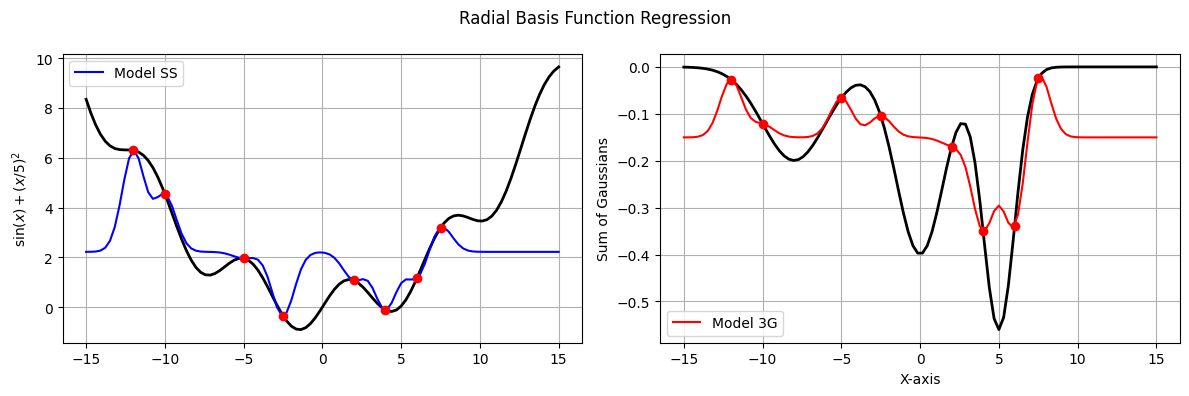

In [37]:
Y_RBF_ss, Y_RBF_3g, x_points  = evalML(x_points, RBF_model_SS, RBF_model_3G)
plot_results(x_points, Y_RBF_ss, Y_RBF_3g, title='Radial Basis Function Regression')

## Decision Trees (DTs)

In [38]:
##########################
# Decision Trees sklearn #
##########################

from sklearn.tree import DecisionTreeRegressor

In [39]:
##########################
# Training Decision Tree #
##########################
# Creating a model that learns the 3 Gaussians function
DT_model_3G   = DecisionTreeRegressor()
DT_model_3G.fit(Xtrain, Ytrain_3g)

# Creating a model that learns the Sin + Square function
DT_model_SS   = DecisionTreeRegressor()
DT_model_SS.fit(Xtrain, Ytrain_ss)

DecisionTreeRegressor()

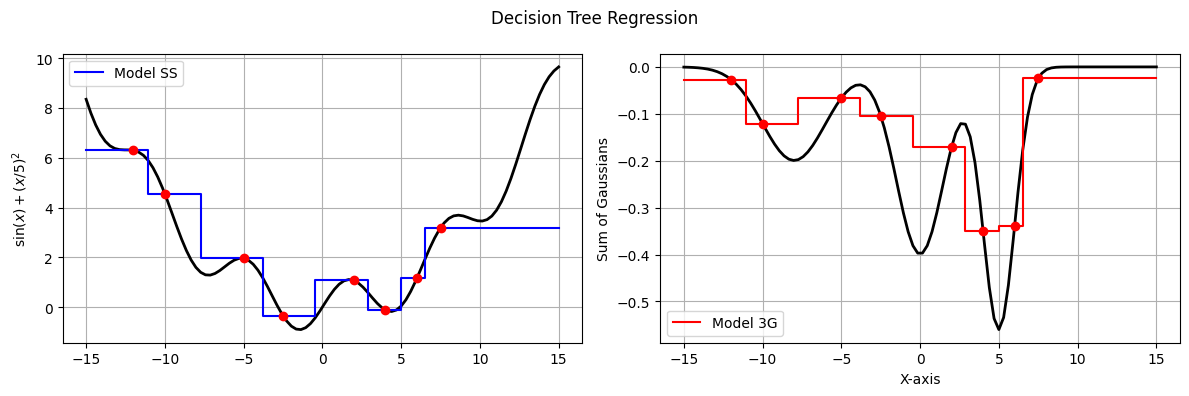

In [40]:
Y_DT_ss, Y_DT_3g, x_points  = evalML(x_points, DT_model_SS, DT_model_3G)
plot_results(x_points, Y_DT_ss, Y_DT_3g, title='Decision Tree Regression', step_plot=True)

In [41]:
##########################
# AdaBoost Trees sklearn #
##########################

from sklearn.ensemble import AdaBoostRegressor

In [42]:
# Creating a model that learns the 3 Gaussians function
AdaB_model_3G = AdaBoostRegressor()
AdaB_model_3G.fit(Xtrain, Ytrain_3g.flatten())

# Creating a model that learns the Sin + Square function
AdaB_model_SS = AdaBoostRegressor()
AdaB_model_SS.fit(Xtrain, Ytrain_ss.flatten())

AdaBoostRegressor()

## Neural Network

In [43]:
###########################
# Neural Networks sklearn #
###########################

# Warning: this is a naive NN implementation.

from sklearn.neural_network import MLPRegressor

In [44]:
##################
# Neural Network #
##################

# Creating a model that learns the Sin + (x/5)^2 function
NN_model_SS = MLPRegressor(random_state=0,
                           learning_rate='adaptive',
                           alpha=0.001,
                           max_iter=10000,
                           solver='lbfgs',
                           activation='relu'
                           )
NN_model_SS.fit(Xtrain, Ytrain_ss.flatten())

# Creating a model that learns the 3 Gaussians function
NN_model_3G = MLPRegressor(random_state=1,
                           learning_rate='adaptive',
                           alpha=0.001,
                           max_iter=10000,
                           solver='lbfgs',
                           activation='relu'
                           )

NN_model_3G.fit(Xtrain, Ytrain_3g.flatten())

MLPRegressor(alpha=0.001, learning_rate='adaptive', max_iter=10000,
             random_state=1, solver='lbfgs')

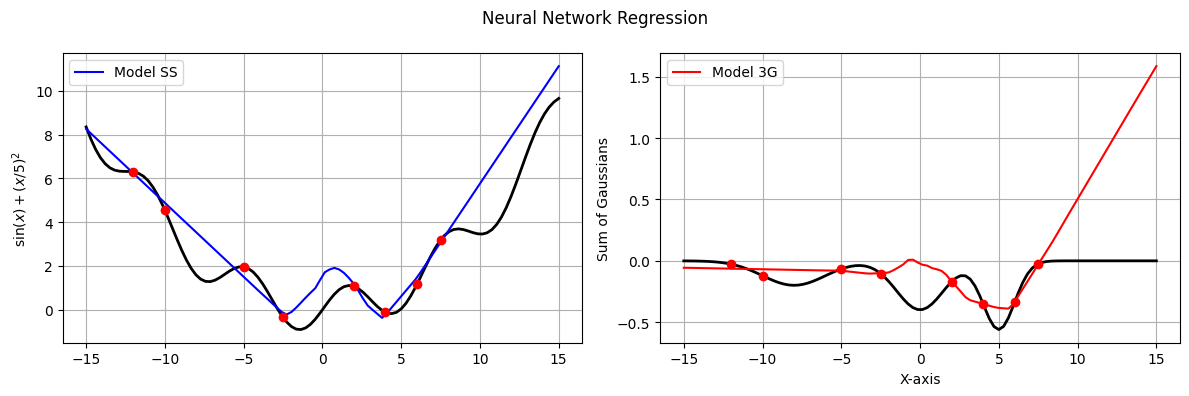

In [45]:
Y_NN_ss, Y_NN_3g, x_points  = evalML(x_points, NN_model_SS, NN_model_3G)
plot_results(x_points, Y_NN_ss, Y_NN_3g, title='Neural Network Regression')

## Gaussian Process

In [46]:
###########################
# Gaussian Process sklearn #
###########################

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

kernelRBF  = RBF()
GPmodel_SS = GaussianProcessRegressor(kernel=kernelRBF,
                                        n_restarts_optimizer=10,
                                        normalize_y=True)
GPmodel_SS.fit(Xtrain, Ytrain_ss)

GPmodel_3G = GaussianProcessRegressor(n_restarts_optimizer=10,
                                        normalize_y=True)
GPmodel_3G.fit(Xtrain, Ytrain_3g)

GaussianProcessRegressor(n_restarts_optimizer=10, normalize_y=True)

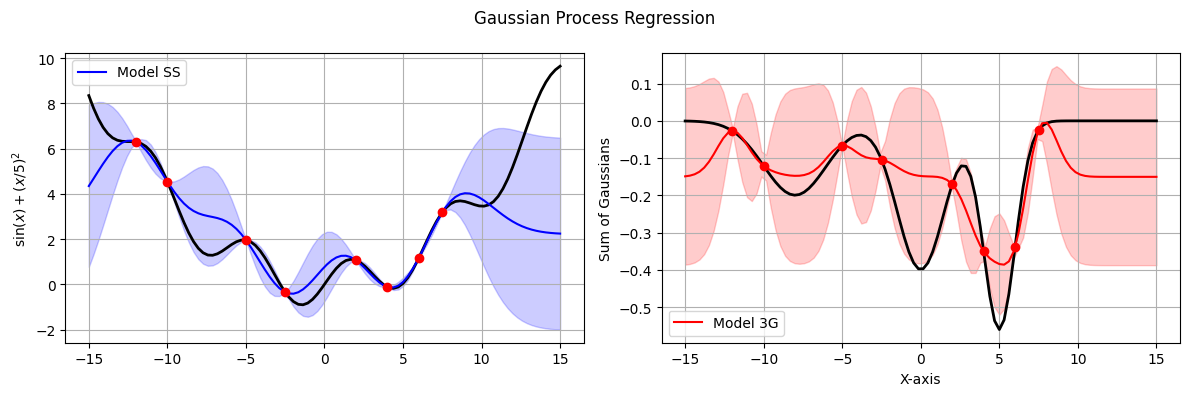

In [47]:
Y_GP_ss, Y_GP_3g, YGP_ss_var, YGP_3g_var  = evalML(x_points,
                                                   GPmodel_SS,
                                                   GPmodel_3G,
                                                   GP_model=True)

plot_results(x_points, Y_GP_ss, Y_GP_3g,
             Yplot_ss_var=YGP_ss_var,
             Yplot_3g_var=YGP_3g_var,
             title='Gaussian Process Regression')
